In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"

# El nombre del fichero puede llevar la fecha de generación como prefijo
candidates = (
    sorted(DATA_DIR.glob("*processed_data_no_duplicates.npz"))
    + sorted(DATA_DIR.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

Usando: /Users/carlasequero/Desktop/trabajo-fin-master/solution/data/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [6]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/dataset_extraction_pipeline/data/06_training_data/training_03.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    gaia_ID = f["gaia_source_id"][:]

print(gaia_ID.shape)

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']
(55621,)


In [7]:
from astropy.table import Table
import numpy as np
from pathlib import Path

# Cargamos la tabla de Gaia guardada en local
gaia_data_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/gaia_data.ecsv")

gaia_data_table = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [8]:
# Usamos solo los id comunes
gaia_data_df_test= gaia_data_df[
    gaia_data_df["source_id"].isin(data["X_id_test"])
].copy()

print(gaia_data_df_test)

                  source_id          ra       dec  phot_bp_mean_mag  \
4            28248000706176   45.006817  0.409473         16.161688   
10           63874753930112   45.441987  0.703435         17.009331   
20           97998269560192   44.625707  0.669816         17.435019   
31          134866268838016   45.166719  1.045718         16.168686   
45          222174363879424   45.604678  1.145428         16.695606   
...                     ...         ...       ...               ...   
126579  6917371144643572992  314.132023 -0.997591         17.373322   
126594  6917426395103598848  315.512299 -0.747515         18.606197   
126607  6917500650793022592  315.010056 -0.406710         16.424784   
126611  6917521949536776960  314.983138 -0.202028         15.553245   
126614  6917526691179095040  314.908073 -0.104466         18.114988   

        phot_rp_mean_mag  phot_bp_mean_flux_over_error  \
4              14.960652                    322.594666   
10             16.275934       

In [9]:
# bp_rp, phot_g_mean_mag, parallax
gaia_data_df_test["abs_g_mag"] = gaia_data_df_test["phot_g_mean_mag"] + 5 * np.log10(gaia_data_df_test["parallax"]) - 10


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
valid_hr = (
    np.isfinite(gaia_data_df_test["bp_rp"])
    & np.isfinite(gaia_data_df_test["abs_g_mag"])
    & np.isfinite(gaia_data_df_test["parallax"])
    & (gaia_data_df_test["parallax"] > 0)
)

gaia_data_df_test = gaia_data_df_test[valid_hr]

Una vez preparado el conjunto de datos, definimos los intervalos a separar teniendo en cuenta el diagrama HR que anteriormente hemos graficado en el archivo HR-diagram.ipynb

In [11]:
# Secuencia principal extremo izquierdo
main_sequence_left = gaia_data_df_test[
    (gaia_data_df_test["bp_rp"] > 0.5)
    & (gaia_data_df_test["bp_rp"] < 1)
    & (gaia_data_df_test["abs_g_mag"] > -10)
    & (gaia_data_df_test["abs_g_mag"] < -3)
]

# Secuencia principal centro
main_sequence_central = gaia_data_df_test[
    (gaia_data_df_test["bp_rp"] > 1)
    & (gaia_data_df_test["bp_rp"] < 2)
    & (gaia_data_df_test["abs_g_mag"] > 5.5)
    & (gaia_data_df_test["abs_g_mag"] < 8.0)
]

# Secuencia principal extremo derecho
main_sequence_right = gaia_data_df_test[
    (gaia_data_df_test["bp_rp"] > 2.5)
    & (gaia_data_df_test["bp_rp"] < 4.2)
    & (gaia_data_df_test["abs_g_mag"] > 12)
    & (gaia_data_df_test["abs_g_mag"] < 16)
]

# Enanas blancas
white_dwarfs = gaia_data_df_test[
    (gaia_data_df_test["bp_rp"] > -0.5)
    & (gaia_data_df_test["bp_rp"] < 1)
    & (gaia_data_df_test["abs_g_mag"] > 10.5)
    & (gaia_data_df_test["abs_g_mag"] < 15)
]

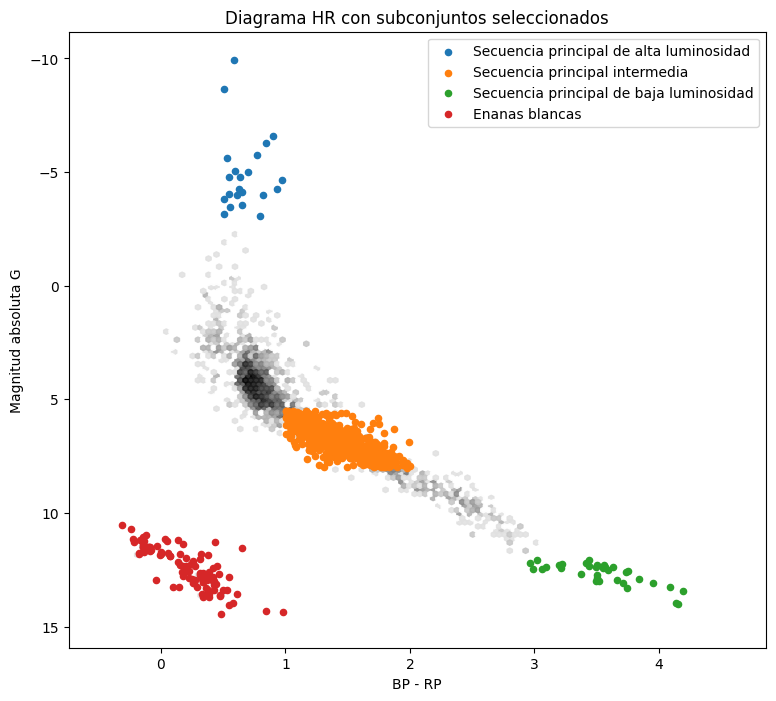

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 8))

# Ponemos todos los datos de fondo con escala de grises para que se marquen las zonas con mas puntos
plt.hexbin(
    gaia_data_df_test["bp_rp"],
    gaia_data_df_test["abs_g_mag"],
    gridsize=120,
    bins="log",
    mincnt=1,
    cmap="Greys",
    alpha=0.9
)

# Secuencia principal - izquierda
plt.scatter(
    main_sequence_left["bp_rp"],
    main_sequence_left["abs_g_mag"],
    s=20,
    label="Secuencia principal de alta luminosidad"
)

# Secuencia principal - centro
plt.scatter(
    main_sequence_central["bp_rp"],
    main_sequence_central["abs_g_mag"],
    s=20,
    label="Secuencia principal intermedia"
)

# Secuencia principal - derecha
plt.scatter(
    main_sequence_right["bp_rp"],
    main_sequence_right["abs_g_mag"],
    s=20,
    label="Secuencia principal de baja luminosidad"
)

# Enanas blancas
plt.scatter(
    white_dwarfs["bp_rp"],
    white_dwarfs["abs_g_mag"],
    s=20,
    label="Enanas blancas"
)

plt.xlabel("BP - RP")
plt.ylabel("Magnitud absoluta G")
plt.title("Diagrama HR con subconjuntos seleccionados")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

Guardaremos los datos para ser identificados y usados más tarde en el trabajo.

In [38]:
for df in [main_sequence_left, main_sequence_central, main_sequence_right, white_dwarfs]:
    indices = []
    for source_id in df["source_id"]:
            matches = np.where(data["X_id_test"] == source_id)[0]

            if len(matches) > 0:
                indices.append(matches[0])
            else:
                indices.append(np.nan)

    df["X_test_index"] = indices

In [ ]:
output_dir = Path("../data/test_categories")
output_dir.mkdir(parents=True, exist_ok=True)

main_sequence_left.to_csv(
    "../data/test_categories/main_sequence_left.csv"
)

main_sequence_central.to_csv(
    "../data/test_categories/main_sequence_central.csv"
)

main_sequence_right.to_csv(
    "../data/test_categories/main_sequence_right.csv"
)

white_dwarfs.to_csv(
    "../data/test_categories/white_dwarfs.csv"
)